# CS 5480: Deep Learning
# Assignment 2 — Coding: Backpropagation from Scratch

**Total: 50 points**

In this notebook you will implement a two-layer MLP and its full forward and backward
passes using **NumPy only** (no PyTorch, no TensorFlow, no autograd). By the end,
you will have a working neural network trained entirely by hand-coded gradient
descent — and you will have verified that your gradients are correct.

The notebook uses **two datasets** intentionally:

- **Parts (a)–(e): `make_moons`** — a synthetic 2D dataset with a clear nonlinear
  boundary. Its simple geometry makes it easy to verify that your implementation
  is working before moving to real data.
- **Parts (f)–(h): Wisconsin Breast Cancer** — a real medical dataset with 30
  features and binary labels (malignant / benign). This is where your trained
  network does something that matters.

This mirrors real practice: *test your implementation on synthetic data,
then apply it to real data.*

| Part | Topic | Dataset | Points |
|------|-------|---------|--------|
| (a) | Forward Pass | make\_moons | 6 |
| (b) | Loss and Output Gradient | make\_moons | 4 |
| (c) | Backward Pass | make\_moons | 14 |
| (d) | Gradient Check | make\_moons | 6 |
| (e) | Training Loop | make\_moons | 6 |
| (f) | Decision Boundary Visualization | Breast Cancer | 6 |
| (g) | Learning Rate Analysis | Breast Cancer | 4 |
| (h) | Depth vs Width Experiment | Breast Cancer | 4 |
| **Total** | | | **50** |

---
### Rules
- Use **NumPy only** for all numerical computations.
- Do **not** import or use any automatic differentiation library.
- All plots must be generated by running this notebook top-to-bottom.
- Write your analysis in the provided **markdown cells** — do not add extra
  code cells for written answers.
- Do not remove or modify provided sanity-check cells.
---

In [1]:
# --- Imports (do not modify) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

---
## Background: The Network Architecture

You will implement a two-layer MLP:

$$
\begin{aligned}
z^{(1)} &= W^{(1)}x + b^{(1)} \\
h       &= \text{ReLU}(z^{(1)}) \\
z^{(2)} &= W^{(2)}h + b^{(2)} \\
\hat{y} &= \sigma(z^{(2)})
\end{aligned}
$$

where $\sigma(z) = \frac{1}{1+e^{-z}}$ and $\text{ReLU}(z) = \max(0,z)$.

The loss for $N$ examples is mean binary cross-entropy:
$$E = -\frac{1}{N}\sum_{n=1}^N \bigl[t_n \ln\hat{y}_n + (1-t_n)\ln(1-\hat{y}_n)\bigr]$$

**Chain rule reminder** (Lecture 10A):
$$\frac{\partial E}{\partial w}
= \underbrace{\frac{\partial E}{\partial z^{\text{out}}}}_\text{upstream}
\times
\underbrace{\frac{\partial z^{\text{out}}}{\partial w}}_\text{local}$$

You will apply this pattern layer-by-layer in Part (c).

---

## Dataset 1: make_moons  (Parts a – e)

A synthetic 2D dataset with a crescent-shaped nonlinear boundary.
Its simple geometry makes it easy to see at a glance whether your
network is learning correctly.

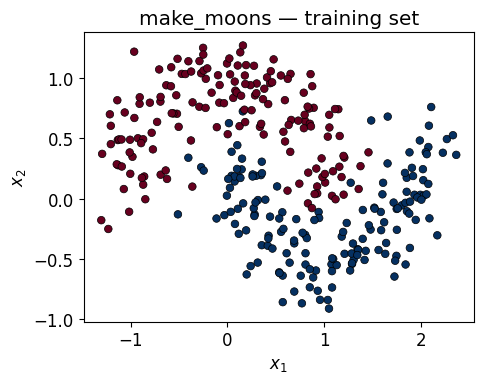

Train: X=(2, 320), t=(1, 320)
Test:  X=(2, 80), t=(1, 80)


In [2]:
# --- make_moons preparation (do not modify) ---
X_m, t_m = make_moons(n_samples=400, noise=0.2, random_state=42)
X_m_tr, X_m_te, t_m_tr, t_m_te = train_test_split(
    X_m, t_m, test_size=0.2, random_state=42
)
# Transpose to (D, N) — our convention throughout
X_m_tr = X_m_tr.T                            # (2, 320)
X_m_te = X_m_te.T                            # (2, 80)
t_m_tr = t_m_tr.reshape(1, -1).astype(float) # (1, 320)
t_m_te = t_m_te.reshape(1, -1).astype(float) # (1, 80)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_m_tr[0], X_m_tr[1], c=t_m_tr.ravel(),
           cmap='RdBu', edgecolors='k', s=30, linewidths=0.5)
ax.set_title('make_moons — training set')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout(); plt.show()
print(f"Train: X={X_m_tr.shape}, t={t_m_tr.shape}")
print(f"Test:  X={X_m_te.shape}, t={t_m_te.shape}")

---
## Part (a): Forward Pass (6 points)

Complete the `MLP` class. The `__init__` method (provided) initializes weights
using He initialization. You must implement:

1. `relu(z)` — ReLU activation
2. `sigmoid(z)` — logistic sigmoid
3. `forward(X)` — full forward pass, **caching** intermediate values

Cache `self.X`, `self.z1`, `self.h`, `self.z2`, `self.y_hat` — the backward
pass will need them.

> **Hint:** Clip `z` to `[-500, 500]` inside `sigmoid` to avoid overflow.

In [3]:
class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim=1, seed=42):
        """He initialization — provided, do not modify."""
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2.0 / input_dim),
                             (hidden_dim, input_dim))
        self.b1 = np.zeros((hidden_dim, 1))
        self.W2 = rng.normal(0, np.sqrt(2.0 / hidden_dim),
                             (output_dim, hidden_dim))
        self.b2 = np.zeros((output_dim, 1))

    def relu(self, z):
        """Element-wise ReLU: max(0, z)."""
        return np.maximum(0, z)

    def sigmoid(self, z):
        """Element-wise sigmoid: 1 / (1 + exp(-z))."""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        """
        Forward pass.

        Args:
            X: shape (D, N)
        Returns:
            y_hat: shape (1, N), values in (0, 1)

        Cache as instance attributes:
            self.X, self.z1, self.h, self.z2, self.y_hat
        """
        self.X = X  # Cache the input
        self.z1 = self.W1 @ X + self.b1
        self.h = self.relu(self.z1)
        self.z2 = self.W2 @ self.h + self.b2
        self.y_hat = self.sigmoid(self.z2)

        return self.y_hat


In [4]:
# --- Sanity check (a) — do not modify ---
np.random.seed(0)
X_toy = np.random.randn(2, 4)
t_toy = np.array([[1, 0, 1, 0]], dtype=float)

net_toy    = MLP(input_dim=2, hidden_dim=3)
y_hat_toy  = net_toy.forward(X_toy)

assert y_hat_toy.shape == (1, 4),                        "Shape mismatch"
assert np.all(y_hat_toy > 0) and np.all(y_hat_toy < 1), "Sigmoid out of range"
print("y_hat:", y_hat_toy)
print("Part (a) passed. ✓")

y_hat: [[0.31101214 0.52798782 0.39642173 0.42317254]]
Part (a) passed. ✓


---
## Part (b): Loss and Output Gradient (4 points)

Implement binary cross-entropy and its gradient with respect to $\hat{y}$:

$$E = -\frac{1}{N}\sum_n\bigl[t_n\ln\hat{y}_n + (1-t_n)\ln(1-\hat{y}_n)\bigr]$$

$$\frac{\partial E}{\partial \hat{y}_n}
= -\frac{1}{N}\left[\frac{t_n}{\hat{y}_n} - \frac{1-t_n}{1-\hat{y}_n}\right]$$

> **Hint:** Add `eps=1e-8` inside the logs to avoid `log(0)`.

In [5]:
def binary_cross_entropy(y_hat, t, eps=1e-8):
    """
    Mean BCE loss.
    Args: y_hat (1,N), t (1,N)  Returns: scalar
    """
    N = y_hat.shape[1]
    loss = -np.sum(
        t * np.log(y_hat + eps) +
        (1 - t) * np.log(1 - y_hat + eps)
    ) / N
    return loss

def bce_grad(y_hat, t, eps=1e-8):
    """
    Gradient of mean BCE w.r.t. y_hat.
    Args: y_hat (1,N), t (1,N)  Returns: (1,N)
    """
    N = y_hat.shape[1]
    grad = -(1 / N) * (
        (t / (y_hat + eps)) - 
        ((1-t) / (1 - y_hat + eps))
    )
    return grad

In [6]:
# --- Sanity check (b) — do not modify ---
y_perfect = np.array([[0.9999, 0.0001]])
y_wrong   = np.array([[0.0001, 0.9999]])
t_check   = np.array([[1.0,    0.0   ]])

loss_perfect = binary_cross_entropy(y_perfect, t_check)
loss_wrong   = binary_cross_entropy(y_wrong,   t_check)

print(f"Loss (correct & confident):  {loss_perfect:.6f}")
print(f"Loss (wrong  & confident):   {loss_wrong:.4f}")
assert loss_perfect < 0.01, "Near-perfect predictions should give ~0 loss"
assert loss_wrong   > 5.0,  "Confident wrong predictions should give high loss"
print("Part (b) passed. ✓")

Loss (correct & confident):  0.000100
Loss (wrong  & confident):   9.2102
Part (b) passed. ✓


---
## Part (c): Backward Pass (14 points)

Implement `backward()` for `MLP` using the **upstream × local** pattern
from Lecture 10A. Work backwards:

$$
\hat{y} \xrightarrow{\sigma} z^{(2)}
       \xrightarrow{W^{(2)},b^{(2)}} h
       \xrightarrow{\text{ReLU}} z^{(1)}
       \xrightarrow{W^{(1)},b^{(1)}} x
$$

**Key derivatives:**

$$\sigma'(z) = \hat{y}(1-\hat{y}) \qquad
  \text{ReLU}'(z) = \mathbb{1}[z>0]$$

For a linear layer $z = Wh + b$ with upstream $\delta_z$:
$$\frac{\partial E}{\partial W} = \delta_z h^\top \qquad
  \frac{\partial E}{\partial b} = \textstyle\sum_{\rm batch}\delta_z \qquad
  \frac{\partial E}{\partial h} = W^\top\delta_z$$

> **Shape guide** ($N$=batch, $D$=input dim, $H$=hidden dim):
>
> `dz2`→(1,N)  `dW2`→(1,H)  `db2`→(1,1)
> `dh` →(H,N)  `dz1`→(H,N)  `dW1`→(H,D)  `db1`→(H,1)

In [7]:
def backward(self, t):
    """
    Backward pass.
    Args:    t  shape (1, N)
    Returns: grads  dict with keys 'W1','b1','W2','b2'
    """
    # Starting upstream signal
    dy_hat = bce_grad(self.y_hat, t)   # (1, N)

    dz2 = dy_hat * self.y_hat * (1 - self.y_hat)
    dW2 = dz2 @ self.h.T
    db2 = dz2.sum(axis=1, keepdims=True)
    dh  = self.W2.T @ dz2

    dz1 = dh * (self.z1 > 0)

    dW1 = dz1 @ self.X.T
    db1 = dz1.sum(axis=1, keepdims=True)

    return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

MLP.backward = backward

In [8]:
# --- Shape check (c) — do not modify ---
net_toy.forward(X_toy)
grads_toy = net_toy.backward(t_toy)

for key, expected in [('W1', net_toy.W1.shape), ('b1', net_toy.b1.shape),
                      ('W2', net_toy.W2.shape), ('b2', net_toy.b2.shape)]:
    assert grads_toy[key] is not None,              f"grads['{key}'] is None"
    assert grads_toy[key].shape == expected, \
        f"grads['{key}']: got {grads_toy[key].shape}, expected {expected}"
    print(f"  grads['{key}'] {grads_toy[key].shape} ✓")
print("Part (c) shape check passed. ✓")

  grads['W1'] (3, 2) ✓
  grads['b1'] (3, 1) ✓
  grads['W2'] (1, 3) ✓
  grads['b2'] (1, 1) ✓
Part (c) shape check passed. ✓


---
## Part (d): Gradient Check (6 points)

Verify your gradients numerically using **centered finite differences**:

$$\frac{\partial E}{\partial w_i}
\approx \frac{E(w_i+\varepsilon)-E(w_i-\varepsilon)}{2\varepsilon}$$

We compare analytic vs numerical via **relative error**:

$$\text{rel. error}
= \frac{|g_{\text{analytic}}-g_{\text{numerical}}|}
       {|g_{\text{analytic}}|+|g_{\text{numerical}}|+10^{-8}}$$

A correct implementation gives errors **below $10^{-4}$** for all parameters.

> The `gradient_check` function is **provided**.
> Your job: run it and report the results.

In [9]:
# --- gradient_check (provided — do not modify) ---
def gradient_check(net, X, t, eps=1e-5):
    net.forward(X)
    analytic = net.backward(t)
    params   = {'W1': net.W1, 'b1': net.b1, 'W2': net.W2, 'b2': net.b2}

    print(f"{'Param':<6} {'Max Rel Error':<20} Status")
    print("-" * 40)
    all_ok = True
    for name in ['W1','b1','W2','b2']:
        param = params[name]
        ng    = np.zeros_like(param)
        it    = np.nditer(param, flags=['multi_index'])
        while not it.finished:
            idx  = it.multi_index
            orig = param[idx]
            param[idx] = orig + eps;  net.forward(X);  lp = binary_cross_entropy(net.y_hat, t)
            param[idx] = orig - eps;  net.forward(X);  lm = binary_cross_entropy(net.y_hat, t)
            ng[idx]    = (lp - lm) / (2 * eps)
            param[idx] = orig
            it.iternext()
        ag      = analytic[name]
        rel_err = np.max(np.abs(ag - ng) / (np.abs(ag) + np.abs(ng) + 1e-8))
        ok      = rel_err < 1e-4
        all_ok  = all_ok and ok
        print(f"{name:<6} {rel_err:<20.2e} {'✓' if ok else '✗  FAIL'}")
    print()
    print("All passed ✓" if all_ok else
          "Some FAILED — fix backward() before continuing.")
    return all_ok

In [10]:
# -------------------------
# TODO (d): Run the gradient check using net_toy, X_toy, t_toy.
# All relative errors must be below 1e-4 before you continue.
# -------------------------

gradient_check(net_toy, X_toy, t_toy)


Param  Max Rel Error        Status
----------------------------------------
W1     1.66e-09             ✓
b1     8.00e-10             ✓
W2     1.09e-11             ✓
b2     2.39e-11             ✓

All passed ✓


np.True_

**Part (d) Analysis**

Report the relative error for each parameter. Did all checks pass?
If any failed, describe what was wrong and how you fixed it.

**Here were the outputs for my checks:**


**W1: 1.66e-09**

**b1: 8.00e-10**

**W2: 1.09e-11**

**b2: 2.39e-11**


**All of my checks passed on the first attempt, so there was no fixing required.**

---
## Part (e): Training Loop (6 points)

Implement the training loop and confirm the network learns on `make_moons`.

Each iteration:
1. Forward pass
2. Compute and record loss
3. Backward pass
4. Parameter update: $\theta \leftarrow \theta - \eta\,\nabla_\theta E$

In [11]:
def train(net: MLP, X, t, learning_rate=0.1, n_epochs=1000, verbose=True):
    """
    Full-batch gradient descent.
    Returns: list of losses (one per epoch).
    """
    loss_history = []
    for epoch in range(n_epochs):
        
        # Forward pass
        y_hat = net.forward(X)

        # Compute loss
        loss = binary_cross_entropy(y_hat, t)
        loss_history.append(loss)

        # Backward pass
        grads = net.backward(t)

        # Paremeter update
        net.W1 -= learning_rate * grads["W1"]
        net.b1 -= learning_rate * grads["b1"]
        net.W2 -= learning_rate * grads["W2"]
        net.b2 -= learning_rate * grads["b2"]

        if verbose and (epoch % 200 == 0 or epoch == n_epochs - 1):
            print(f"Epoch {epoch:>5d} | Loss: {loss_history[-1]:.6f}")
    return loss_history

Epoch     0 | Loss: 0.559718
Epoch   200 | Loss: 0.287532
Epoch   400 | Loss: 0.271928
Epoch   600 | Loss: 0.266054
Epoch   800 | Loss: 0.262203
Epoch   999 | Loss: 0.259737


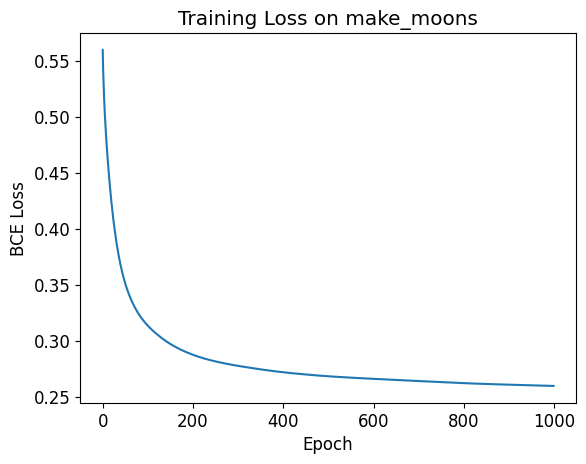

In [12]:
# -------------------------
# TODO (e.2): Train MLP(input_dim=2, hidden_dim=16) on make_moons.
# Use lr=0.1, n_epochs=1000.
# Plot the loss curve (x=epoch, y=loss, with title and axis labels).
# -------------------------

net = MLP(input_dim=2, hidden_dim=16)

# Train
loss_history = train(net, X_m_tr, t_m_tr, learning_rate=0.1, n_epochs=1000)

# Plot
plt.plot(loss_history)
plt.title("Training Loss on make_moons")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.show()


**Part (e) Analysis**

Describe the shape of the loss curve. Does it decrease smoothly?
What does a smoothly decreasing curve tell you about correctness?

**The loss curve decreases smoothly, similar to an exponential decay. There are no visible spikes or oscillations.**

**A smoothly decreasing curve shows that the forward and backward passes are implemented correctly, as the parameter updates are moving smoothly and consistently in the correct direction to reduce the loss.**

---
## Dataset 2: Wisconsin Breast Cancer  (Parts f – h)

The Wisconsin Breast Cancer dataset contains **569 tumour measurements**,
each described by **30 numerical features** (radius, texture, smoothness, …).
The binary label is:
- **0 = malignant** (cancerous)
- **1 = benign** (non-cancerous)

This dataset connects directly to the **decision theory** question in the
theory section.  The two error types are not equally costly:
a *false negative* (predicting benign when the tumour is malignant) is
far more dangerous than a *false positive*.

**Why we standardize:**
The 30 features span very different scales
(e.g. mean radius ≈ 10–28 vs mean fractal dimension ≈ 0.05–0.10).
Without standardization gradient descent converges poorly.
We fit a `StandardScaler` on the training set and apply it to both splits.

**Why we use PCA for visualization:**
With 30 features we cannot plot the true decision boundary directly.
We project to 2D using PCA *for visualization only* — the network
trains and predicts in the full 30-dimensional space.

> ⚠️  **The decision boundaries in Parts (f) and (h) are shown in a
> 2D PCA projection, not in the original feature space.**
> This is standard practice in high-dimensional ML.
> The visualization reflects model behaviour in a reduced subspace,
> not the full geometry of the decision surface.

Train: X=(30, 455), t=(1, 455)
Test:  X=(30, 114), t=(1, 114)
PCA variance explained: 63.4%


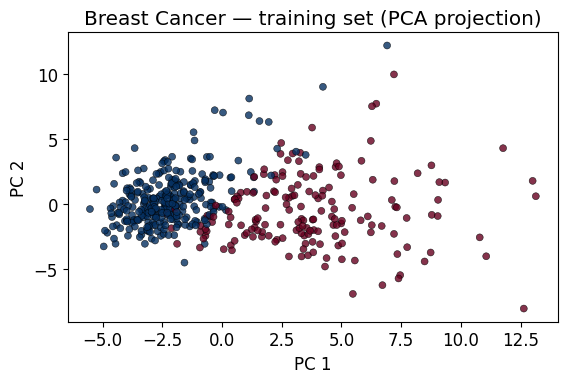

In [13]:
# --- Breast Cancer preparation (do not modify) ---
bc           = load_breast_cancer()
X_bc_raw     = bc.data    # (569, 30)
t_bc_raw     = bc.target  # (569,)  0=malignant, 1=benign

X_tr_raw, X_te_raw, t_bc_tr, t_bc_te = train_test_split(
    X_bc_raw, t_bc_raw, test_size=0.2, random_state=42, stratify=t_bc_raw
)

scaler   = StandardScaler()
X_bc_tr  = scaler.fit_transform(X_tr_raw).T             # (30, 455)
X_bc_te  = scaler.transform(X_te_raw).T                 # (30, 114)
t_bc_tr  = t_bc_tr.reshape(1, -1).astype(float)        # (1, 455)
t_bc_te  = t_bc_te.reshape(1, -1).astype(float)        # (1, 114)

# PCA in standardized space (visualization only)
pca          = PCA(n_components=2, random_state=42)
X_bc_tr_2d   = pca.fit_transform(scaler.transform(X_tr_raw))  # (455, 2)
X_bc_te_2d   = pca.transform(scaler.transform(X_te_raw))      # (114, 2)

print(f"Train: X={X_bc_tr.shape}, t={t_bc_tr.shape}")
print(f"Test:  X={X_bc_te.shape}, t={t_bc_te.shape}")
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_bc_tr_2d[:,0], X_bc_tr_2d[:,1],
           c=t_bc_tr.ravel(), cmap='RdBu',
           edgecolors='k', s=25, linewidths=0.4, alpha=0.8)
ax.set_title('Breast Cancer — training set (PCA projection)')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
plt.tight_layout(); plt.show()

---
## Part (f): Decision Boundary Visualization (6 points)

Train two networks on the **full 30-dimensional** breast cancer features
and compare their decision boundaries in the **PCA projection**.

The helper `plot_boundary_pca` is provided. It creates a grid in PCA space,
inverse-transforms each point to 30D, and queries the network for predictions.

In [14]:
# --- plot_boundary_pca (provided — do not modify) ---
def plot_boundary_pca(net, X_2d, t, pca_obj, title='', ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    xmn,xmx = X_2d[:,0].min()-0.5, X_2d[:,0].max()+0.5
    ymn,ymx = X_2d[:,1].min()-0.5, X_2d[:,1].max()+0.5
    xx,yy   = np.meshgrid(np.linspace(xmn,xmx,200), np.linspace(ymn,ymx,200))
    grid_30d = pca_obj.inverse_transform(np.c_[xx.ravel(),yy.ravel()]).T
    probs    = net.forward(grid_30d).reshape(xx.shape)
    ax.contourf(xx,yy,probs, levels=50, cmap='RdBu', alpha=0.6, vmin=0,vmax=1)
    ax.contour( xx,yy,probs, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X_2d[:,0], X_2d[:,1], c=t.ravel(), cmap='RdBu',
               edgecolors='k', s=25, linewidths=0.4, alpha=0.8)
    ax.set_title(title); ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    return ax

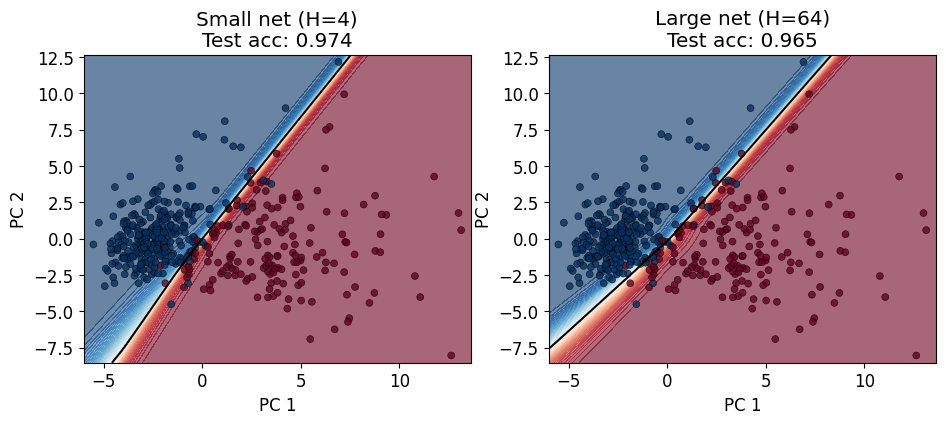

In [15]:
# -------------------------
# TODO (f):
# Train two networks on (X_bc_tr, t_bc_tr):
#   net_small : MLP(input_dim=30, hidden_dim=4),  lr=0.05, n_epochs=2000
#   net_large : MLP(input_dim=30, hidden_dim=64), lr=0.05, n_epochs=2000
#
# Plot side-by-side boundaries with plt.subplots(1,2,figsize=(11,4)).
# Title each panel with hidden dim and test accuracy.
#
# Test accuracy:
#   preds = (net.forward(X_bc_te) >= 0.5).astype(float)
#   acc   = (preds == t_bc_te).mean()
# -------------------------

def test_accuracy(net, X, t):
    y_hat = net.forward(X)
    preds = (y_hat >= 0.5).astype(float)
    return (preds == t).mean()

# small network
net_small = MLP(input_dim=30, hidden_dim=4)
loss_small = train(net_small, X_bc_tr, t_bc_tr, learning_rate=0.05, n_epochs=2000, verbose=False)
acc_small = test_accuracy(net_small, X_bc_te, t_bc_te)

# large network
net_large = MLP(input_dim=30, hidden_dim=64)
loss_large = train(net_large, X_bc_tr, t_bc_tr, learning_rate=0.05, n_epochs=2000, verbose=False)
acc_large = test_accuracy(net_large, X_bc_te, t_bc_te)

# Plot decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_boundary_pca(net_small, X_bc_tr_2d, t_bc_tr, pca, ax=axes[0])
axes[0].set_title(f"Small net (H=4)\nTest acc: {acc_small:.3f}")
plot_boundary_pca(net_large, X_bc_tr_2d, t_bc_tr, pca, ax=axes[1])
axes[1].set_title(f"Large net (H=64)\nTest acc: {acc_large:.3f}")
plt.show()


**Part (f) Analysis**

1. Which network produces a smoother decision boundary? Which achieves
   higher test accuracy? Connect to **model capacity** (Lecture 4 / AS1).

**The smaller netword (H=4) gives a smoother decision boundary, while the large network has a more wobbly boundary.** 

**The smaller network also achieved a higher accuracy than the larger model (0.974 vs. 0.965). This shows the bias-variance tradeoff, where the larger model with higher variance/capacity overfits the data, causing it to have a lower overall accuracy than the simpler model.**

2. The PCA projection explains the percentage of variance printed above.
   What does this tell you about the limitations of this visualization?

**PCA only explains 63.4% of the variance, so the 2D visualization doesn't fully capture the full 30-dimensional feature space. This means that the decision boundaries plotted here are just approximations.**

3. In the cancer screening context, would you prefer to minimize
   false negatives or maximize overall accuracy? How does this connect
   to the decision theory question in the theory section?

**In cancer screening, minimizing false negatives (missing actual cancer patients) is far more important than maximizing overall accuracy. This relates directly to the question about cost-sensitive classification, where each outcome is given a cost/weight which is used to prioritize it (more than just raw accuracy).**

---
## Part (g): Learning Rate Analysis (4 points)

Train the same architecture (`input_dim=30, hidden_dim=16`) with three
different learning rates and plot all three loss curves on one figure.

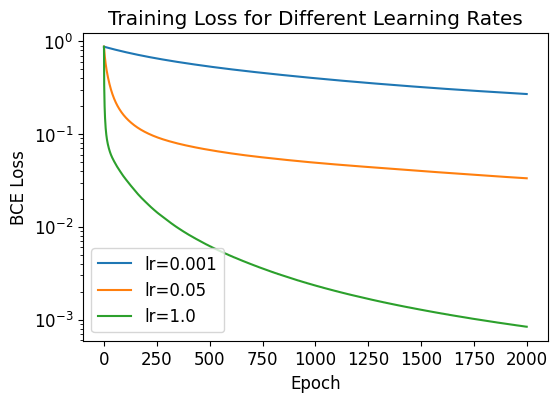

In [16]:
# -------------------------
# TODO (g): learning rates [0.001, 0.05, 1.0], n_epochs=2000 each.
#
# Single figure:
#   - log-scale y-axis  (plt.yscale('log'))
#   - legend with learning rate labels
#   - title and axis labels
# -------------------------

learning_rates = [0.001, 0.05, 1.0]
n_epochs = 2000

plt.figure(figsize=(6, 4))

for lr in learning_rates:
    net = MLP(input_dim=30, hidden_dim=16)
    loss_history = train(net, X_bc_tr, t_bc_tr, learning_rate=lr, n_epochs=n_epochs, verbose=False)
    plt.plot(loss_history, label=f"lr={lr}")

plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss for Different Learning Rates")
plt.legend()
plt.show()


**Part (g) Analysis**

Describe what you observe for each learning rate and connect each
behaviour to the gradient descent discussion from Lecture 8.
What does the largest learning rate's curve tell you about step size
and the local geometry of the loss surface?

- `lr = 0.001`: **The loss decreases very slowly. Each step is tiny, so convergence will take many more epochs.**
- `lr = 0.05`: **The loss shows a "normal" decreasing curve, decreasing quickly at the start and beginning to stabilize around 0.1 BCE.**
- `lr = 1.0`: **The loss decreases even more rapidly, continuing to drop until reaching BCE 0.001 by the final epoch.**

**The largest LR's curve indicates that the step size is large relative to the curvature of the loss surface, allowing the model to move rapidly toward the minimum. Because the curve remains smooth without oscillations, the surface is well-conditioned and the larger step does not overshoot or diverge.**

---
## Part (h): Depth vs Width Experiment (4 points)

Compare a **wide shallow** network against a **narrow deep** network
with approximately the same number of parameters.

A `DeepMLP` supporting multiple hidden layers is provided below.
Architecture is specified as a list: `[input_dim, h1, h2, …, output_dim]`.

In [17]:
# --- DeepMLP (provided — do not modify) ---
class DeepMLP:
    """
    Flexible MLP: hidden layers use ReLU, output uses sigmoid.
    layer_dims: list, e.g. [30,64,1] or [30,8,8,8,1]
    """
    def __init__(self, layer_dims, seed=42):
        rng = np.random.default_rng(seed)
        self.weights, self.biases = [], []
        for i in range(len(layer_dims)-1):
            W = rng.normal(0, np.sqrt(2.0/layer_dims[i]),
                           (layer_dims[i+1], layer_dims[i]))
            self.weights.append(W)
            self.biases.append(np.zeros((layer_dims[i+1],1)))

    def relu(self,z):    return np.maximum(0,z)
    def sigmoid(self,z): return 1/(1+np.exp(-np.clip(z,-500,500)))

    def forward(self, X):
        self.cache = []
        a = X
        for i,(W,b) in enumerate(zip(self.weights,self.biases)):
            z = W@a+b
            self.cache.append((a,z))
            a = self.relu(z) if i<len(self.weights)-1 else self.sigmoid(z)
        self.y_hat = a
        return self.y_hat

    def backward(self, t):
        dWs, dbs = [], []
        da = bce_grad(self.y_hat, t)
        ap,z = self.cache[-1]
        dz = da*self.y_hat*(1-self.y_hat)
        dWs.insert(0, dz@ap.T); dbs.insert(0, dz.sum(1,keepdims=True))
        da = self.weights[-1].T@dz
        for i in reversed(range(len(self.weights)-1)):
            ap,z = self.cache[i]
            dz   = da*(z>0).astype(float)
            dWs.insert(0, dz@ap.T); dbs.insert(0, dz.sum(1,keepdims=True))
            da   = self.weights[i].T@dz
        return dWs, dbs

    def train_step(self, X, t, lr):
        self.forward(X)
        loss = binary_cross_entropy(self.y_hat, t)
        dWs, dbs = self.backward(t)
        for i in range(len(self.weights)):
            self.weights[i] -= lr*dWs[i]
            self.biases[i]  -= lr*dbs[i]
        return loss


def train_deep(net, X, t, lr=0.05, n_epochs=2000):
    """Training loop for DeepMLP. Provided — do not modify."""
    return [net.train_step(X, t, lr) for _ in range(n_epochs)]


def plot_boundary_pca_deep(net, X_2d, t, pca_obj, title='', ax=None):
    """PCA boundary plot for DeepMLP. Provided — do not modify."""
    if ax is None: _, ax = plt.subplots(figsize=(5,4))
    xmn,xmx = X_2d[:,0].min()-0.5, X_2d[:,0].max()+0.5
    ymn,ymx = X_2d[:,1].min()-0.5, X_2d[:,1].max()+0.5
    xx,yy   = np.meshgrid(np.linspace(xmn,xmx,200), np.linspace(ymn,ymx,200))
    g30     = pca_obj.inverse_transform(np.c_[xx.ravel(),yy.ravel()]).T
    probs   = net.forward(g30).reshape(xx.shape)
    ax.contourf(xx,yy,probs,levels=50,cmap='RdBu',alpha=0.6,vmin=0,vmax=1)
    ax.contour( xx,yy,probs,levels=[0.5],colors='k',linewidths=1.5)
    ax.scatter(X_2d[:,0],X_2d[:,1],c=t.ravel(),cmap='RdBu',
               edgecolors='k',s=25,linewidths=0.4,alpha=0.8)
    ax.set_title(title); ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    return ax

Wide shallow test accuracy:  0.965
Narrow deep  test accuracy:  0.974


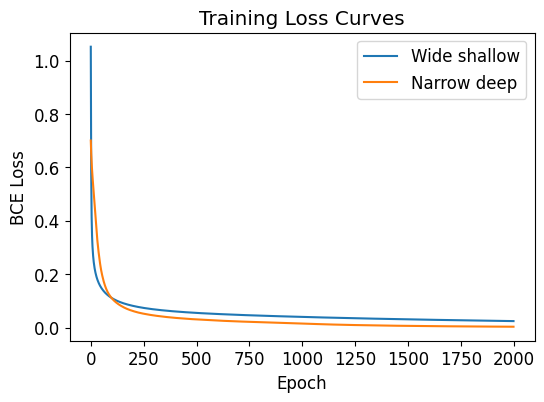

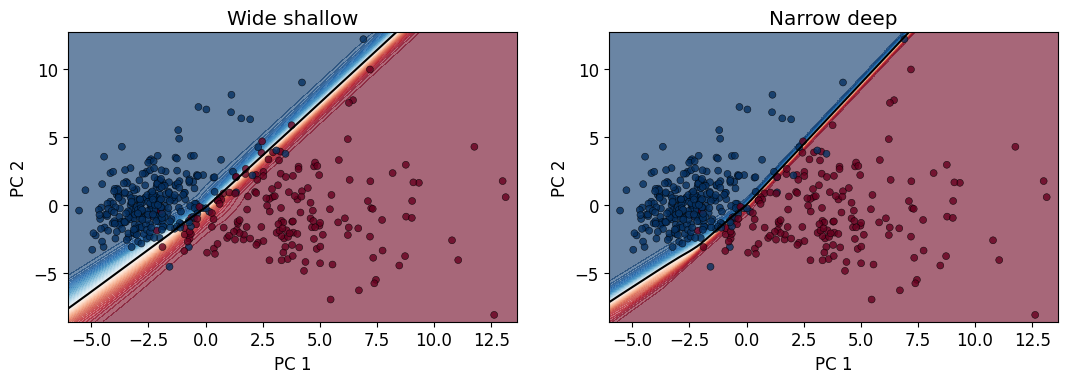

In [18]:
# -------------------------
# TODO (h):
#
# Network A  wide  shallow : layer_dims = [30, 64, 1]
#   params ≈ 30*64+64 + 64*1+1 = 2,049
#
# Network B  narrow deep   : layer_dims = [30, 16, 16, 16, 1]
#   params ≈ 30*16+16 + 16*16+16 + 16*16+16 + 16+1 = 1,073
#
# Train both: lr=0.05, n_epochs=2000.
# Print test accuracy for each.
#
# Figure 1: loss curves for A and B on the same axes.
# Figure 2: decision boundaries side by side (plot_boundary_pca_deep).
# -------------------------

# Build networks
net_wide  = DeepMLP([30, 64, 1], seed=42)
net_deep  = DeepMLP([30, 16, 16, 16, 1], seed=42)

# Train
loss_wide = train_deep(net_wide, X_bc_tr, t_bc_tr, lr=0.05, n_epochs=2000)
loss_deep = train_deep(net_deep, X_bc_tr, t_bc_tr, lr=0.05, n_epochs=2000)

# Get accuracy
preds_wide = (net_wide.forward(X_bc_te) >= 0.5).astype(float)
acc_wide   = (preds_wide == t_bc_te).mean()
preds_deep = (net_deep.forward(X_bc_te) >= 0.5).astype(float)
acc_deep   = (preds_deep == t_bc_te).mean()
print(f"Wide shallow test accuracy:  {acc_wide:.3f}")
print(f"Narrow deep  test accuracy:  {acc_deep:.3f}")

# Plot loss
plt.figure(figsize=(6,4))
plt.plot(loss_wide, label='Wide shallow')
plt.plot(loss_deep, label='Narrow deep')
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.show()

# Plot boundaries
fig, axes = plt.subplots(1, 2, figsize=(11,4))
plot_boundary_pca_deep(net_wide, X_bc_tr_2d, t_bc_tr, pca, title=f"Wide shallow", ax=axes[0])
plot_boundary_pca_deep(net_deep, X_bc_tr_2d, t_bc_tr, pca, title=f"Narrow deep", ax=axes[1])
plt.tight_layout()
plt.show()


**Part (h) Analysis**

Answer in 4–6 sentences:

1. Which network converges faster?

**The wide, shallow network converges slightly faster than the narrow, deep network**

2. Which achieves higher test accuracy?

**The narrow, deep network achieves a higher test accuracy (0.974) than the wide, shallow network (0.965)**

3. Both have a similar parameter count. What does this suggest about the role of **depth vs width**?

**Although the wide shallow network has more units in a single hidden layer, the narrow deep network can represent more complex functions with fewer neurons per layer. This shows that depth allows the network to compose features, capturing interactions that the shallow network cannot.**

4. Connect to the discussion of depth and hierarchical representations from Lecture 6.

**As discussed in Lecture 6, deeper networks can build new, abstract features from the inputs layer by layer. This makes the problem simpler, breaking down a complex problem into smaller parts until the final neuron simply solves the linear relation.**

---
## Submission Checklist

Before submitting (`Kernel → Restart & Run All`):

- [X] Notebook runs **top-to-bottom without errors**
- [X] All `TODO` blocks completed (no `pass` or `None` remaining)
- [X] All sanity checks print a **pass / ✓** message
- [X] Gradient check **(d)**: all relative errors **below $10^{-4}$**
- [X] Every plot has **title, axis labels, legend** where required
- [X] All **analysis markdown cells** filled with complete sentences
- [X] Part (f) analysis addresses the **false negative vs false positive** question
- [X] File saved as **`assignment2_backprop.ipynb`**

---
*CS 5480: Deep Learning — Assignment 2 Coding*